Loaded 3755 trials
Layers present: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60)]
Strengths present: [np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0), np.float64(16.0)]
Conditions: {'control': 1252, 'inject_correct': 1252, 'inject_random': 1251}


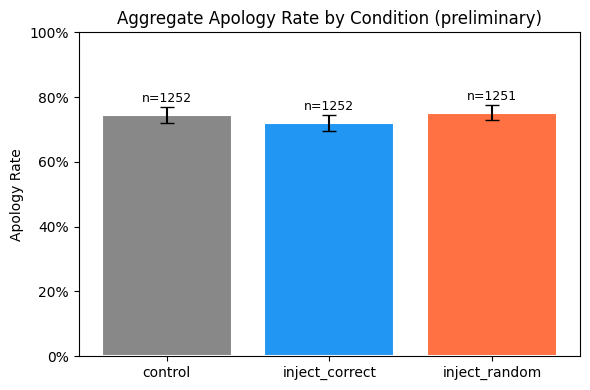

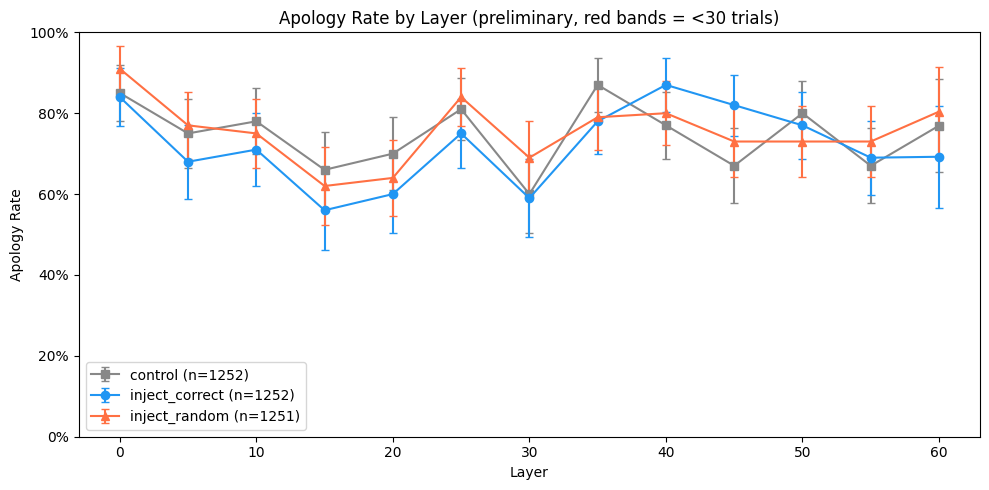

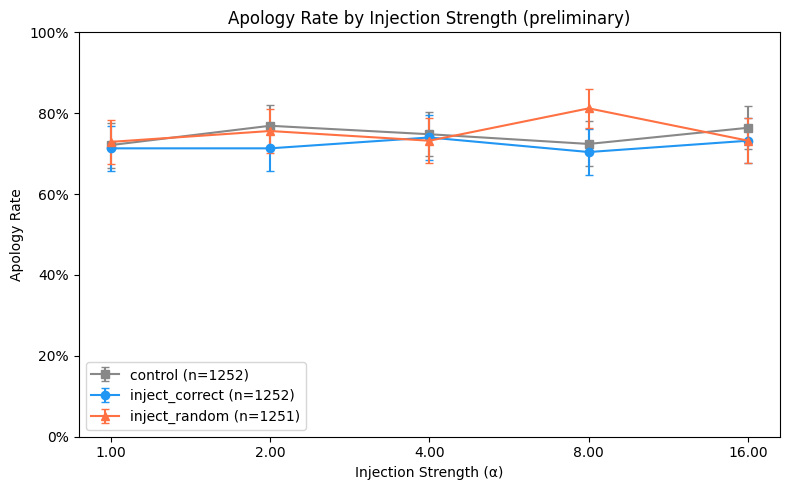

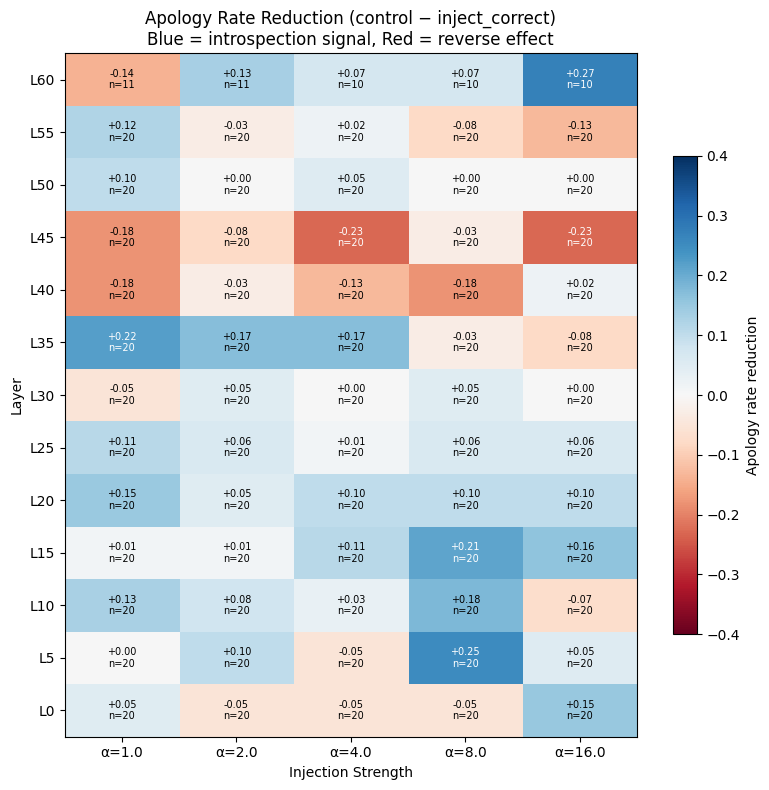

Coverage: 195/255 cells have data (76%)
Total trials: 3755

Trials per layer:
layer
0     300
5     300
10    300
15    300
20    300
25    300
30    300
35    300
40    300
45    300
50    300
55    300
60    155

Min trials per filled cell: 10
Median trials per filled cell: 20


In [5]:
"""
Prefill Detection — Preliminary Apology Rate Visualization
===========================================================
For incomplete runs. Shows what we have so far with trial counts.
"""

# %%
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

RESULTS_PATH = Path("data/results/prefill_detection/results.jsonl")

# Load trials
trials = []
with open(RESULTS_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            trials.append(json.loads(line))

df = pd.DataFrame(trials)
print(f"Loaded {len(df)} trials")
print(f"Layers present: {sorted(df['layer'].unique())}")
print(f"Strengths present: {sorted(df['strength'].unique())}")
print(f"Conditions: {df['condition'].value_counts().to_dict()}")

# Compute apology flag
df["is_apology"] = (df["judgment"] == "apology").astype(int)

# %% [markdown]
# ## 1. Aggregate apology rate by condition (headline result)

# %%
fig, ax = plt.subplots(figsize=(6, 4))

agg = df.groupby("condition").agg(
    apology_rate=("is_apology", "mean"),
    se=("is_apology", "sem"),
    n=("is_apology", "count"),
).reindex(["control", "inject_correct", "inject_random"])

colors = {"control": "#888888", "inject_correct": "#2196F3", "inject_random": "#FF7043"}
bars = ax.bar(
    agg.index, agg["apology_rate"],
    yerr=1.96 * agg["se"],
    capsize=5,
    color=[colors[c] for c in agg.index],
    edgecolor="white", linewidth=1.5,
)

ax.set_ylabel("Apology Rate")
ax.set_title("Aggregate Apology Rate by Condition (preliminary)")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Annotate with n
for bar, (_, row) in zip(bars, agg.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
        f"n={int(row['n'])}", ha="center", va="bottom", fontsize=9,
    )

plt.tight_layout()
plt.savefig("apology_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ## 2. Apology rate by layer (collapsed across strengths)

# %%
fig, ax = plt.subplots(figsize=(10, 5))

for condition, color, marker in [
    ("control", "#888888", "s"),
    ("inject_correct", "#2196F3", "o"),
    ("inject_random", "#FF7043", "^"),
]:
    sub = df[df["condition"] == condition]
    by_layer = sub.groupby("layer").agg(
        apology_rate=("is_apology", "mean"),
        se=("is_apology", "sem"),
        n=("is_apology", "count"),
    ).sort_index()

    ax.errorbar(
        by_layer.index, by_layer["apology_rate"],
        yerr=1.96 * by_layer["se"],
        label=f"{condition} (n={sub.shape[0]})",
        marker=marker, capsize=3, linewidth=1.5, color=color,
    )

# Mark layers with low trial counts
trial_counts = df.groupby("layer").size()
low_n_layers = trial_counts[trial_counts < 30].index
for l in low_n_layers:
    ax.axvline(l, color="red", alpha=0.15, linewidth=8)

ax.set_xlabel("Layer")
ax.set_ylabel("Apology Rate")
ax.set_title("Apology Rate by Layer (preliminary, red bands = <30 trials)")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.savefig("apology_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ## 3. Apology rate by strength (collapsed across layers)

# %%
fig, ax = plt.subplots(figsize=(8, 5))

for condition, color, marker in [
    ("control", "#888888", "s"),
    ("inject_correct", "#2196F3", "o"),
    ("inject_random", "#FF7043", "^"),
]:
    sub = df[df["condition"] == condition]
    by_str = sub.groupby("strength").agg(
        apology_rate=("is_apology", "mean"),
        se=("is_apology", "sem"),
        n=("is_apology", "count"),
    ).sort_index()

    ax.errorbar(
        by_str.index, by_str["apology_rate"],
        yerr=1.96 * by_str["se"],
        label=f"{condition} (n={sub.shape[0]})",
        marker=marker, capsize=3, linewidth=1.5, color=color,
    )

ax.set_xlabel("Injection Strength (α)")
ax.set_ylabel("Apology Rate")
ax.set_title("Apology Rate by Injection Strength (preliminary)")
ax.set_ylim(0, 1)
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(mtick.ScalarFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.savefig("apology_by_strength.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ## 4. Heatmap: apology rate reduction (inject_correct vs control) by layer × strength

# %%
# Pivot apology rates
pivot_correct = df[df["condition"] == "inject_correct"].groupby(
    ["layer", "strength"])["is_apology"].mean().unstack("strength")
pivot_control = df[df["condition"] == "control"].groupby(
    ["layer", "strength"])["is_apology"].mean().unstack("strength")

# For control, strength doesn't matter (no injection), so use global mean per layer
control_by_layer = df[df["condition"] == "control"].groupby("layer")["is_apology"].mean()

# Reduction: positive = inject_correct reduces apology rate (evidence of introspection)
reduction = pd.DataFrame(index=pivot_correct.index, columns=pivot_correct.columns)
for strength in pivot_correct.columns:
    reduction[strength] = control_by_layer - pivot_correct[strength]

reduction = reduction.astype(float)

# Trial count per cell
n_per_cell = df[df["condition"] == "inject_correct"].groupby(
    ["layer", "strength"]).size().unstack("strength").fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(reduction.values, cmap="RdBu", aspect="auto",
               vmin=-0.4, vmax=0.4, origin="lower")

ax.set_xticks(range(len(reduction.columns)))
ax.set_xticklabels([f"α={s}" for s in reduction.columns])
ax.set_yticks(range(len(reduction.index)))
ax.set_yticklabels([f"L{l}" for l in reduction.index])

# Annotate cells with n
for i, layer in enumerate(reduction.index):
    for j, strength in enumerate(reduction.columns):
        val = reduction.iloc[i, j]
        n = n_per_cell.iloc[i, j] if (layer in n_per_cell.index and strength in n_per_cell.columns) else 0
        text = f"{val:+.2f}\nn={n}" if not np.isnan(val) else "—"
        color = "white" if abs(val) > 0.2 else "black"
        ax.text(j, i, text, ha="center", va="center", fontsize=7, color=color)

ax.set_xlabel("Injection Strength")
ax.set_ylabel("Layer")
ax.set_title("Apology Rate Reduction (control − inject_correct)\nBlue = introspection signal, Red = reverse effect")
fig.colorbar(im, ax=ax, label="Apology rate reduction", shrink=0.7)
plt.tight_layout()
plt.savefig("apology_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ## 5. Coverage: how complete is the run?

# %%
expected_layers = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 79]
expected_strengths = [1, 2, 4, 8, 16]
conditions = ["control", "inject_correct", "inject_random"]

coverage = df.groupby(["layer", "strength", "condition"]).size().reset_index(name="n")
total_cells = len(expected_layers) * len(expected_strengths) * len(conditions)
filled_cells = len(coverage)
print(f"Coverage: {filled_cells}/{total_cells} cells have data ({filled_cells/total_cells*100:.0f}%)")
print(f"Total trials: {len(df)}")
print(f"\nTrials per layer:")
print(df.groupby("layer").size().to_string())
print(f"\nMin trials per filled cell: {coverage['n'].min()}")
print(f"Median trials per filled cell: {coverage['n'].median():.0f}")